In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("D:/thin/P2P_Visual.csv")
boolean_cols = df.select_dtypes(include=['bool']).columns
df[boolean_cols] = df[boolean_cols].astype(int)
df

,Unnamed: 0,acc_now_delinq,acc_open_past_24mths,annual_inc,badloan,chargeoff_within_12_mths,collections_12_mths_ex_med,delinq_2yrs,delinq_amnt,dti,...,num_tl_30dpd,open_acc,pct_tl_nvr_dlq,pub_rec,pub_rec_bankruptcies,purpose,pymnt_plan,revol_util,sub_grade,term
0,0,0,2,49800.0,0,0,0,0,0,25.120001,...,0,8,90.000000,0,0,debt_consolidation,n,0.906,C2,36 months
1,1,0,3,34000.0,0,0,0,0,0,9.220000,...,0,3,100.000000,0,0,debt_consolidation,n,0.929,D2,36 months
2,2,0,0,34000.0,0,0,0,0,0,25.590000,...,0,3,85.000000,0,0,debt_consolidation,n,0.000,A5,36 months
3,3,0,2,50000.0,1,0,0,0,0,9.310000,...,0,4,100.000000,0,0,major_purchase,n,0.559,B5,36 months
4,4,0,2,29000.0,1,0,0,0,0,8.150000,...,0,4,100.000000,0,0,debt_consolidation,n,0.828,B4,36 months
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2703425,2703425,0,0,50000.0,0,0,0,0,0,16.750000,...,0,4,87.500000,0,0,credit_card,n,0.912,C3,60 months
2703426,2703426,0,3,56000.0,0,0,0,0,0,24.750000,...,0,13,100.000000,1,1,moving,n,0.614,B1,36 months
2703427,2703427,0,4,105000.0,0,0,0,0,0,21.780001,...,0,5,100.000000,0,0,other,n,0.953,A4,36 months
2703428,2703428,0,4,66560.0,0,0,0,0,0,29.100000,...,0,10,100.000000,0,0,credit_card,n,0.501,B1,60 months


In [ ]:
df.columns

Index(['Unnamed: 0', 'acc_now_delinq', 'acc_open_past_24mths', 'annual_inc',
       'badloan', 'chargeoff_within_12_mths', 'collections_12_mths_ex_med',
       'delinq_2yrs', 'delinq_amnt', 'dti', 'earnings', 'emp_length',
       'funded_amnt', 'grade', 'home_ownership', 'inq_last_12m',
       'inq_last_6mths', 'installment', 'int_rate', 'loan_amnt', 'loan_status',
       'loan_status_5', 'loan_sum', 'loan_vol6m', 'mort_acc',
       'mths_since_last_delinq', 'num_accts_ever_120_pd', 'num_actv_rev_tl',
       'num_tl_30dpd', 'open_acc', 'pct_tl_nvr_dlq', 'pub_rec',
       'pub_rec_bankruptcies', 'purpose', 'pymnt_plan', 'revol_util',
       'sub_grade', 'term'],
      dtype='object')

In [ ]:
import seaborn as sns

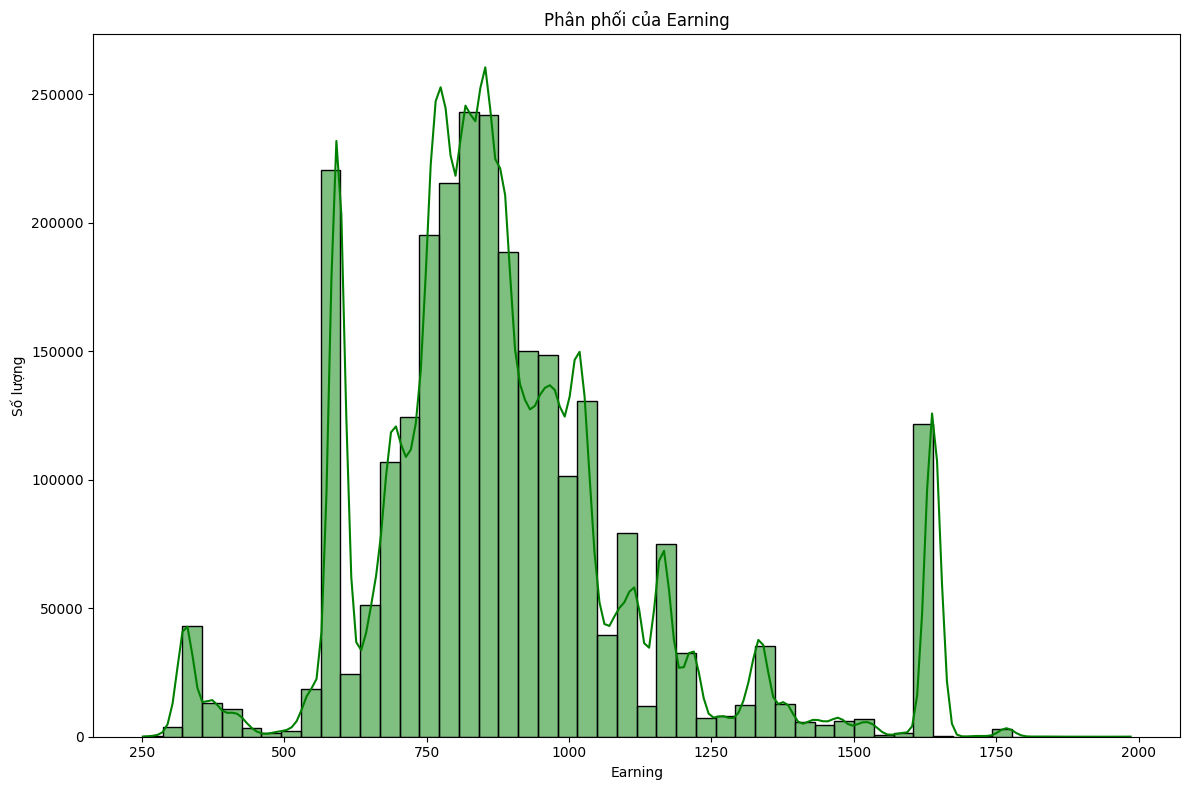

In [ ]:
# Biểu đồ Histogram của earnings
plt.figure(figsize=(12, 8))
sns.histplot(df['earnings'], bins=50, kde=True, color='green')
plt.title("Phân phối của Earning")
plt.xlabel("Earning")
plt.ylabel("Số lượng")
plt.tight_layout()
plt.show()

C:\Users\MT\AppData\Local\Temp\ipykernel_7728\1204928210.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['emp_length'], order=sorted(df['emp_length'].dropna().unique()), palette="coolwarm")


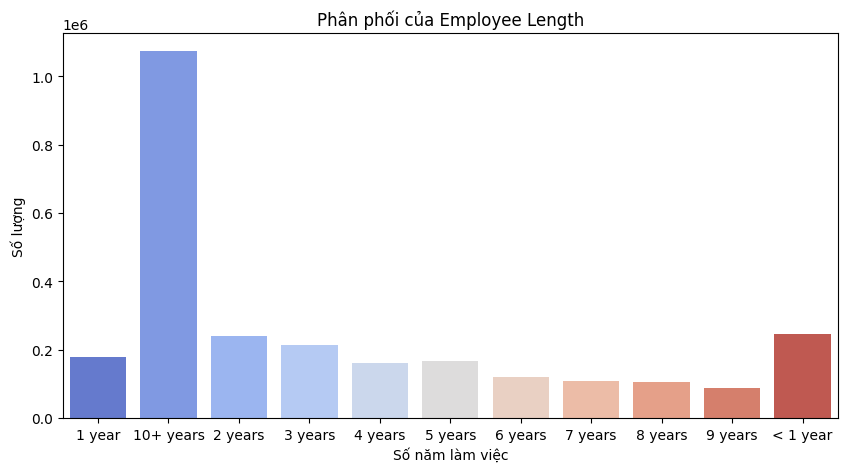

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(x=df['emp_length'], order=sorted(df['emp_length'].dropna().unique()), palette="coolwarm")
plt.title("Phân phối của Employee Length")
plt.xlabel("Số năm làm việc")
plt.ylabel("Số lượng")
plt.show()

In [ ]:
df["home_ownership"]

0          MORTGAGE
1               OWN
2              RENT
3              RENT
4              RENT
             ...   
2703425        RENT
2703426        RENT
2703427    MORTGAGE
2703428    MORTGAGE
2703429    MORTGAGE
Name: home_ownership, Length: 2703430, dtype: object

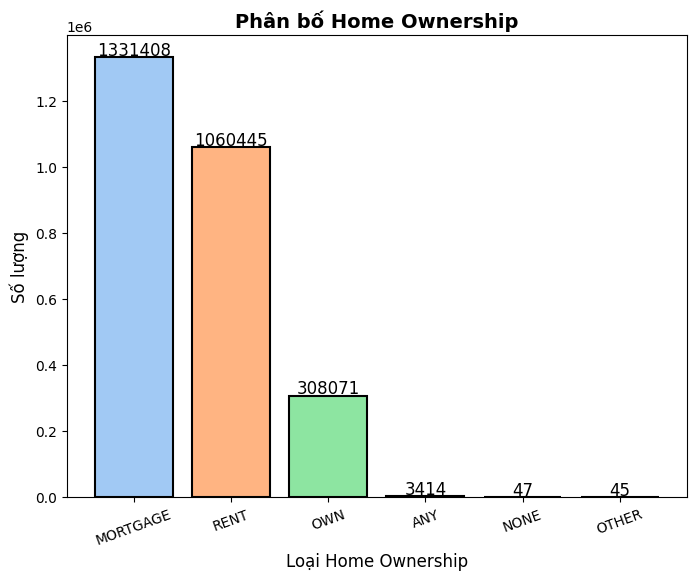

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 🔹 Đếm số lượng từng loại
counts = df["home_ownership"].value_counts()

# 🎨 Màu sắc pastel dịu mắt
colors = sns.color_palette("pastel")

# 📊 Vẽ biểu đồ cột
plt.figure(figsize=(8, 6))
bars = plt.bar(counts.index, counts.values, color=colors, edgecolor="black", linewidth=1.5)

# 🏷️ Thêm nhãn số lượng lên cột
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
             f"{int(bar.get_height())}", ha="center", fontsize=12)

# 🎯 Thiết lập tiêu đề và nhãn trục
plt.title("Phân bố Home Ownership", fontsize=14, fontweight="bold")
plt.xlabel("Loại Home Ownership", fontsize=12)
plt.ylabel("Số lượng", fontsize=12)
plt.xticks(rotation=20)  # Xoay nhãn trục x cho dễ đọc
plt.show()

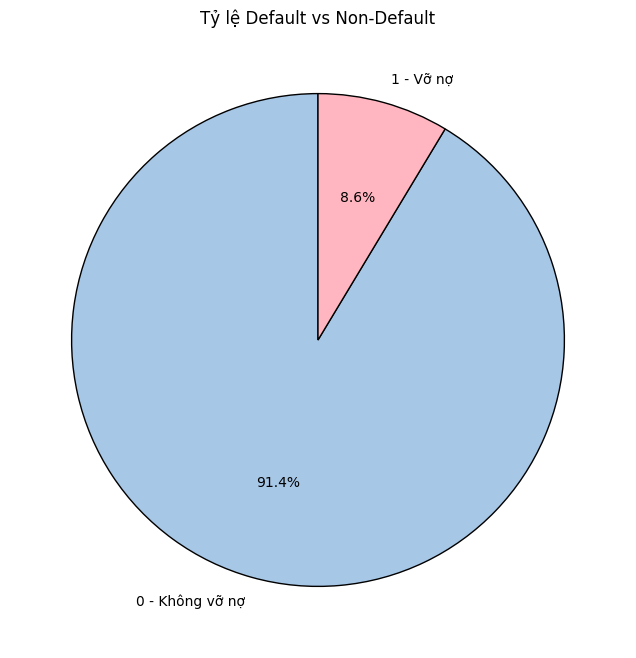

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 🔹 Đếm số lượng từng loại trong default_binary
binary_counts = df["default_binary"].value_counts()

# 🎨 Màu sắc dịu mắt (pastel)
colors = ["#A7C7E7", "#FFB6C1"]  # Màu xanh pastel và hồng pastel

# 🎯 Nhãn tương ứng
labels = ["0 - Không vỡ nợ", "1 - Vỡ nợ"]

# 📊 Vẽ biểu đồ tròn
plt.figure(figsize=(8, 8))
plt.pie(binary_counts, labels=labels, autopct="%1.1f%%",
        colors=colors, startangle=90, wedgeprops={"edgecolor": "black"})

plt.title("Tỷ lệ Default vs Non-Default")
plt.show()

In [ ]:
df["sub_grade"]

0          11
1          16
2           4
3           9
4           8
           ..
2703425    12
2703426     5
2703427     3
2703428     5
2703429     9
Name: sub_grade, Length: 2703430, dtype: int64

In [ ]:
df["sub_grade"].value_counts()

sub_grade
B4    172518
C1    168355
B5    166506
B1    151702
B2    151694
C2    151526
C3    150357
B3    149362
C4    145880
C5    140351
A4    139447
A5    137198
A1    118775
D2    100262
D1     95966
A3     93763
A2     91732
D3     76664
D4     62659
D5     53616
E1     33505
E2     29150
E3     26216
E5     22606
E4     22309
F1     12812
F2      8836
F3      7432
F4      5820
F5      4926
G1      3887
G2      2539
G3      1994
G4      1599
G5      1466
Name: count, dtype: int64

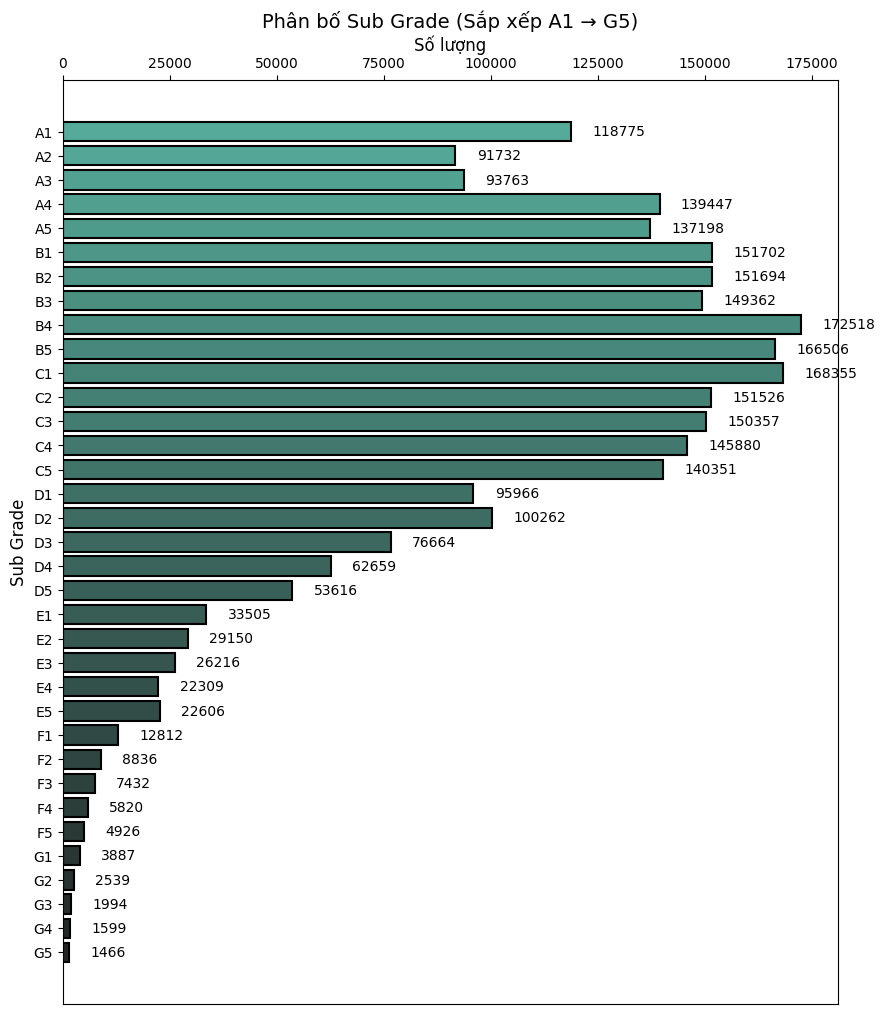

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 🔹 Thứ tự mong muốn từ A1 đến G5
order = [
    "A1", "A2", "A3", "A4", "A5",
    "B1", "B2", "B3", "B4", "B5",
    "C1", "C2", "C3", "C4", "C5",
    "D1", "D2", "D3", "D4", "D5",
    "E1", "E2", "E3", "E4", "E5",
    "F1", "F2", "F3", "F4", "F5",
    "G1", "G2", "G3", "G4", "G5"
]

# 🔹 Đếm số lượng từng loại trong sub_grade
sub_grade_counts = df["sub_grade"].value_counts()

# 🔹 Sắp xếp đúng thứ tự mong muốn
sub_grade_counts = sub_grade_counts.reindex(order).dropna()

# 🎨 Màu sắc dịu mắt
colors = sns.color_palette("dark:#5A9_r", len(sub_grade_counts))

# 📊 Vẽ biểu đồ thanh ngang
plt.figure(figsize=(10, 12))
bars = plt.barh(sub_grade_counts.index, sub_grade_counts.values,
                color=colors, edgecolor="black", linewidth=1.5)

# 🏷️ Thêm nhãn số lượng vào thanh
for bar in bars:
    plt.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
             f"{int(bar.get_width())}", va="center", fontsize=10)

# 🎯 Thiết lập tiêu đề và nhãn trục
plt.title("Phân bố Sub Grade (Sắp xếp A1 → G5)", fontsize=14, fontweight="light")
plt.ylabel("Sub Grade", fontsize=12)
plt.xlabel("Số lượng", fontsize=12)

# 🔄 Đưa trục X lên trên (đưa nhãn số lượng xuống dưới)
plt.gca().xaxis.set_ticks_position("top")  # Đưa ticks của trục X lên trên
plt.gca().xaxis.set_label_position("top")  # Đưa nhãn của trục X lên trên
plt.gca().invert_yaxis()  # Giữ đúng thứ tự A1 -> G5

# 🚀 Hiển thị biểu đồ
plt.show()
